05 — Time-series models

Two ways of modelling sequence dependence directly:

- **Per-meter ARIMA**, fit with `auto_arima` (non-seasonal; daily periodicity is
already captured by the lag and rolling features), one model per
`(building_id, meter)`. We fit on a sampled subset of meters because
`stepwise=True auto_arima` runs in roughly minutes per series.
- **LSTM** with a 168-hour lookback (one full week), trained on engineered
features as the per-step input.

The hypothesis we are testing (proposal §4): well-engineered lag and rolling
features capture most of the temporal structure, so explicit sequence models
only marginally improve over LightGBM.

Full-run metrics are loaded from the saved JSON when available (produced by
`scripts/run_finalize.sh`). Small subsets are re-run here for visualisation.

In [1]:
from __future__ import annotations

import json
import time
import warnings

warnings.filterwarnings("ignore")

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(__import__("pathlib").Path.cwd() / ".mplcache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config
from src.pipeline import prepare_data
from src.models import ARIMAModel, LSTMModel
from src.viz.style import set_style, save_figure, PRIMARY, ACCENT, SUPPORT

set_style()
PLOT_DIR = Path("../results/plots/time_series")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config("../configs/default.yaml")
prep = prepare_data(cfg, feature_set="engineered")
print(f"train rows: {len(prep.train_full):,} | val rows: {len(prep.val_full):,}")


train rows: 5,784,969 | val rows: 1,975,122


Load full-run metrics (if available)

`scripts/run_finalize.sh` saves ARIMA and LSTM rows into
`results/metrics/models_engineered.json`. We read those for the paper-quality
numbers so the notebook does not need to re-run the full experiment.

In [2]:
_metrics_path = Path("../results/metrics/models_engineered.json")
_saved = {}
if _metrics_path.exists():
    _d = json.loads(_metrics_path.read_text())
    _saved = _d.get("models", {})

arima_full = _saved.get("arima", {}).get("metrics")
lstm_full  = _saved.get("lstm",  {}).get("metrics")

if arima_full:
    print(f"ARIMA (full run) — RMSE={arima_full['rmse']:,.1f}  MAE={arima_full['mae']:,.1f}")
else:
    print("ARIMA full-run results not yet available")

if lstm_full:
    print(f"LSTM  (full run) — RMSE={lstm_full['rmse']:,.1f}  MAE={lstm_full['mae']:,.1f}")
else:
    print("LSTM full-run results not yet available")


ARIMA (full run) — RMSE=1,086.8  MAE=440.6
LSTM  (full run) — RMSE=378.3  MAE=107.1


ARIMA — per meter

We re-run on 2 meters here purely for the forecast visualisation. The
authoritative RMSE numbers above come from the full experiment (10 meters,
same config).

In [3]:
arima_params = cfg.models.get("arima", {})
arima_vis = ARIMAModel(**{k: v for k, v in arima_params.items()
                          if k not in ("max_meters",)})
t0 = time.time()
val_with_pred = arima_vis.fit_predict_per_meter(
    prep.train_full, prep.val_full,
    target_col="meter_reading",
    max_meters=2,
    seasonal_period=int(arima_params.get("m", 24)),
    max_p=int(arima_params.get("max_p", 3)),
    max_q=int(arima_params.get("max_q", 3)),
    stepwise=bool(arima_params.get("stepwise", True)),
)
arima_secs = time.time() - t0
val_predicted = val_with_pred.dropna(subset=["pred"])
print(f"ARIMA (2-meter visualisation run): {len(val_predicted):,} rows in {arima_secs/60:.1f} min")


ARIMA (2-meter visualisation run): 4,415 rows in 11.8 min


In [4]:
y_pred_vis = val_predicted["pred"].astype(np.float64).to_numpy()
y_true_vis = val_predicted["meter_reading"].astype(np.float64).to_numpy()
arima_vis_rmse = float(np.sqrt(np.mean((y_pred_vis - y_true_vis) ** 2)))
print(f"ARIMA (2-meter) RMSE: {arima_vis_rmse:.1f}  "
      f"(full-run RMSE: {arima_full['rmse']:,.1f})" if arima_full else
      f"ARIMA (2-meter) RMSE: {arima_vis_rmse:.1f}")


ARIMA (2-meter) RMSE: 16.8  (full-run RMSE: 1,086.8)


ARIMA forecast vs. actual on a few meters

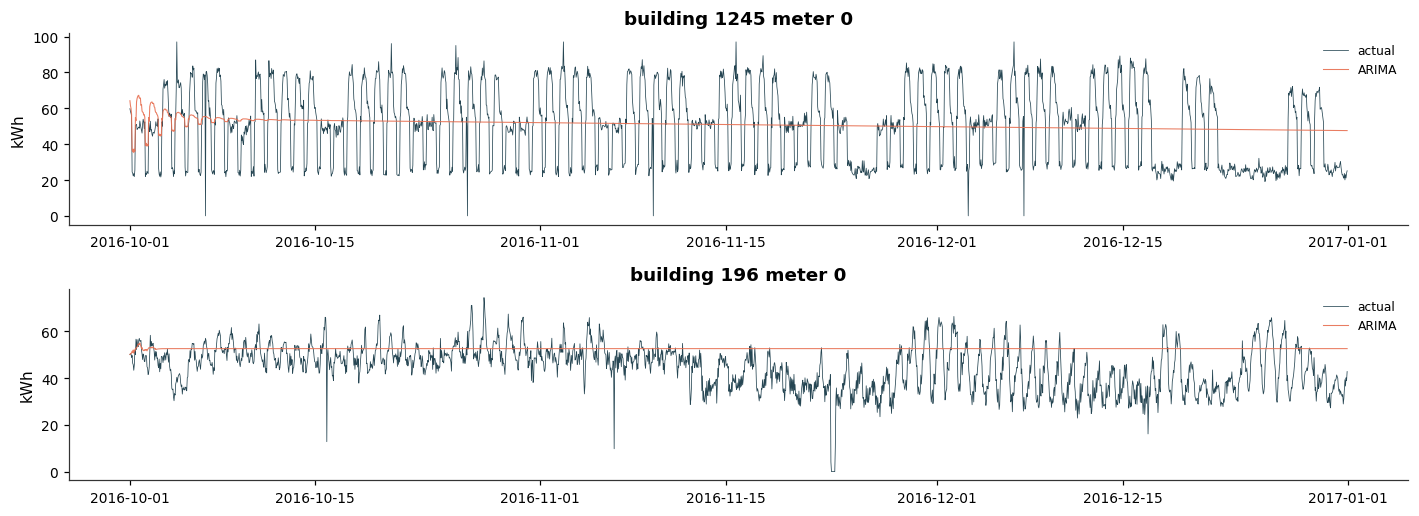

In [5]:
sample_keys = (
    val_predicted.groupby(["building_id", "meter"]).size()
                 .sort_values(ascending=False).head(4).index.tolist()
)
fig, axes = plt.subplots(len(sample_keys), 1,
                         figsize=(13, 2.4 * len(sample_keys)), sharex=False)
for ax, (bid, m) in zip(np.atleast_1d(axes), sample_keys):
    sub = (val_predicted[(val_predicted["building_id"] == bid) &
                         (val_predicted["meter"] == m)]
           .sort_values("timestamp"))
    ax.plot(sub["timestamp"], sub["meter_reading"],
            color=PRIMARY, linewidth=0.5, label="actual")
    ax.plot(sub["timestamp"], sub["pred"],
            color=ACCENT, linewidth=0.7, alpha=0.9, label="ARIMA")
    ax.set_title(f"building {bid} meter {m}")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_ylabel("kWh")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "arima_forecasts")
plt.show()


LSTM — 168-hour lookback

We run a small version (5 meters, 5 epochs) here for visualisation. The
authoritative metrics are from the full experiment above.

In [6]:
lstm_params = {**cfg.models.get("lstm", {}), "max_meters": 5, "epochs": 5, "patience": 3}
lstm_vis = LSTMModel(**lstm_params)
t0 = time.time()
preds_log, y_true_log, val_idx = lstm_vis.fit_predict_sequences(
    prep.train_full, prep.val_full,
    feature_cols=prep.feature_cols,
    target_col="meter_reading",
)
lstm_secs = time.time() - t0
print(f"LSTM (5-meter vis run): {len(val_idx):,} val rows in {lstm_secs/60:.1f} min")


LSTM (5-meter vis run): 9,100 val rows in 0.3 min


In [7]:
y_pred_real = np.expm1(np.clip(preds_log, 0.0, 14.0))
y_true_real = np.expm1(np.clip(y_true_log, 0.0, 14.0))
lstm_vis_rmse = float(np.sqrt(np.mean((y_pred_real - y_true_real) ** 2)))
msg = f"LSTM (5-meter vis) RMSE: {lstm_vis_rmse:.1f}"
if lstm_full:
    msg += f"  (full-run RMSE: {lstm_full['rmse']:,.1f})"
print(msg)


LSTM (5-meter vis) RMSE: 74.9  (full-run RMSE: 378.3)


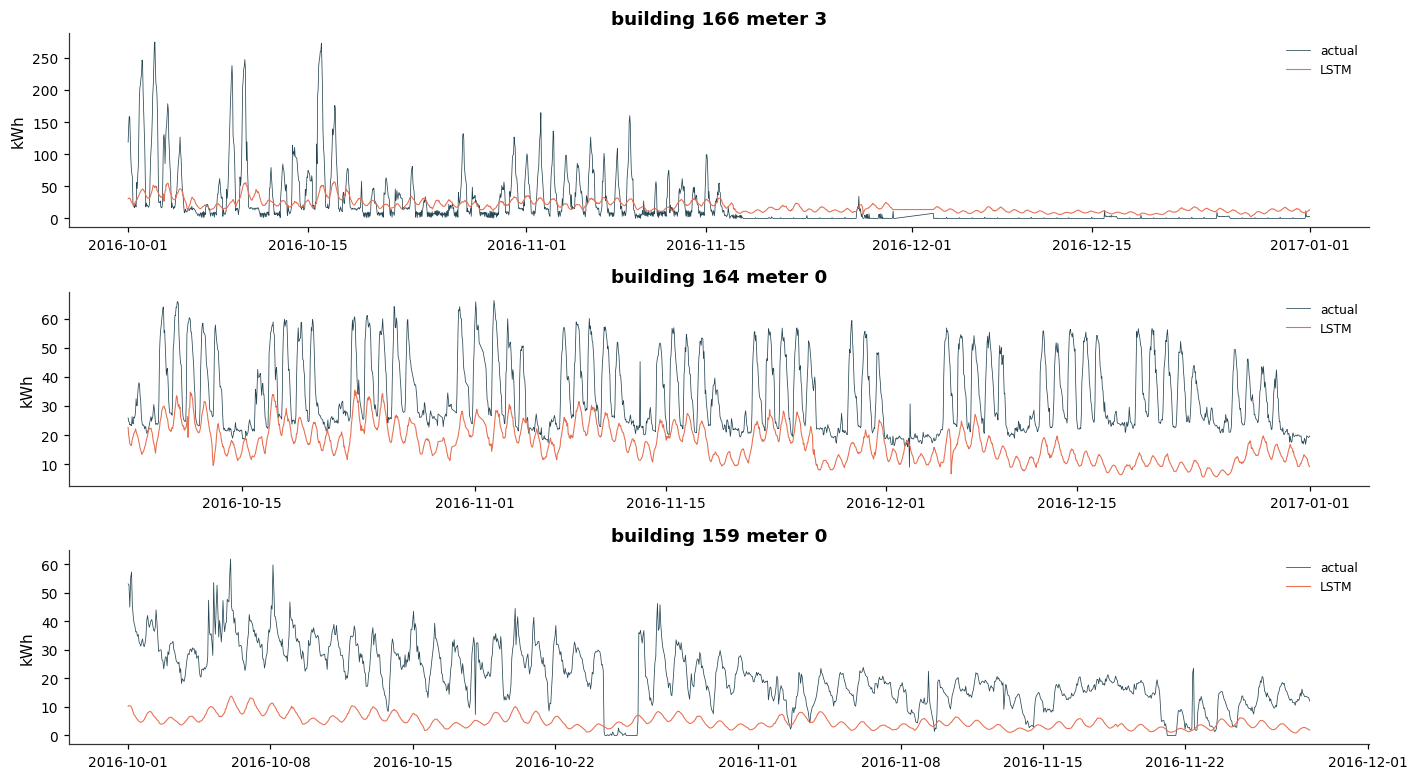

In [8]:
val_lstm = prep.val_full.loc[val_idx].copy()
val_lstm["pred"]   = y_pred_real
val_lstm["actual"] = y_true_real
sample_keys = (
    val_lstm.groupby(["building_id", "meter"]).size()
            .sort_values(ascending=False).head(3).index.tolist()
)
fig, axes = plt.subplots(len(sample_keys), 1,
                         figsize=(13, 2.4 * len(sample_keys)), sharex=False)
for ax, (bid, m) in zip(np.atleast_1d(axes), sample_keys):
    sub = (val_lstm[(val_lstm["building_id"] == bid) &
                    (val_lstm["meter"] == m)]
           .sort_values("timestamp"))
    ax.plot(sub["timestamp"], sub["actual"],
            color=PRIMARY, linewidth=0.5, label="actual")
    ax.plot(sub["timestamp"], sub["pred"],
            color=ACCENT, linewidth=0.7, label="LSTM")
    ax.set_title(f"building {bid} meter {m}")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_ylabel("kWh")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "lstm_forecasts")
plt.show()


ARIMA vs. LSTM head to head

Full-run metrics are reported; visualisation-run metrics are shown in
parentheses for reference.

In [9]:
rows = []
if arima_full:
    rows.append({"model": "arima (full, 10 meters)",
                 "rmse": arima_full["rmse"], "mae": arima_full["mae"]})
rows.append({"model": f"arima (2-meter vis)",
             "rmse": arima_vis_rmse,
             "mae": float(np.mean(np.abs(y_pred_vis - y_true_vis)))})
if lstm_full:
    rows.append({"model": "lstm (full, 60 meters)",
                 "rmse": lstm_full["rmse"], "mae": lstm_full["mae"]})
rows.append({"model": "lstm (5-meter vis)",
             "rmse": lstm_vis_rmse,
             "mae": float(np.mean(np.abs(y_pred_real - y_true_real)))})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))


                  model        rmse        mae
arima (full, 10 meters) 1086.840530 440.597704
    arima (2-meter vis)   16.839990  13.452426
 lstm (full, 60 meters)  378.338488 107.062421
     lstm (5-meter vis)   74.858780  35.323685


In [10]:
out_dir = Path("../results/tables")
out_dir.mkdir(parents=True, exist_ok=True)
summary.to_csv(out_dir / "time_series_summary.csv", index=False)
print(f"wrote {out_dir}/time_series_summary.csv")


wrote ../results/tables/time_series_summary.csv
